In [146]:
# @title 1. 环境设置与依赖项安装
# ------------------------------------------------------------------------------
# 清理可能已存在的旧的仓库目录，确保全新克隆
# ------------------------------------------------------------------------------
!rm -rf /content/Time-Series-Library
!rm -rf /content/NAB
print("Cleaned up any existing Time-Series-Library and NAB directories.")

# ------------------------------------------------------------------------------
# 克隆 TimesNet 代码库 (来自THUML) 和 NAB 数据集代码库
# ------------------------------------------------------------------------------
!git clone https://github.com/thuml/Time-Series-Library.git /content/Time-Series-Library
print("Time-Series-Library (containing TimesNet) repository cloned.")
!git clone https://github.com/numenta/NAB.git /content/NAB
print("NAB repository cloned.")

# ------------------------------------------------------------------------------
# 将代码库的路径添加到 sys.path
# ------------------------------------------------------------------------------
import sys
TIMESNET_PATH = '/content/Time-Series-Library'
if TIMESNET_PATH not in sys.path:
    sys.path.insert(0, TIMESNET_PATH)
print(f"Path '{TIMESNET_PATH}' added to sys.path.")

# ------------------------------------------------------------------------------
# 安装必要的依赖
# ------------------------------------------------------------------------------
!pip install einops pandas numpy matplotlib scikit-learn torch torchvision torchaudio sympy statsmodels filterpy -q
print("Installed/checked necessary packages (including statsmodels and filterpy).")

# ------------------------------------------------------------------------------
# 导入标准库
# ------------------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import json
import os

# ------------------------------------------------------------------------------
# 新增：导入季节性分解和卡尔曼滤波所需的库
# ------------------------------------------------------------------------------
from statsmodels.tsa.seasonal import seasonal_decompose
from filterpy.kalman import KalmanFilter
print("Imported seasonal_decompose and KalmanFilter.")



# ------------------------------------------------------------------------------
# 从克隆的库中导入 TimesNet 模型类
# ------------------------------------------------------------------------------
try:
    from models.TimesNet import Model as TimesNetModel
    print("Successfully imported TimesNet model class as TimesNetModel.")
except ImportError as e:
    print(f"ERROR: Could not import TimesNet model: {e}")
    print("Please check the file structure in '/content/Time-Series-Library/models/' and ensure cloning was successful.")
    if os.path.exists(os.path.join(TIMESNET_PATH, 'models')):
         print(f"Listing files in '{TIMESNET_PATH}/models/': {os.listdir(os.path.join(TIMESNET_PATH, 'models'))}")
    raise
except Exception as e_other:
    print(f"An unexpected error occurred during TimesNet import: {e_other}")
    raise

# ------------------------------------------------------------------------------
# 设置设备 (GPU 或 CPU)
# ------------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------------------------
# 打印环境信息
# ------------------------------------------------------------------------------
print(f"\n--- Environment Setup ---")
print(f"Using device: {device}")
print(f"PyTorch Version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"CUDA available. GPU: {torch.cuda.get_device_name(0)}")
    if hasattr(torch.version, 'cuda'):
        print(f"PyTorch built with CUDA version: {torch.version.cuda}")
else:
    print("CUDA not available. Running on CPU.")
print(f"--- Setup Complete ---")

Cleaned up any existing Time-Series-Library and NAB directories.
Cloning into '/content/Time-Series-Library'...
remote: Enumerating objects: 2023, done.
remote: Counting objects: 100% (1211/1211), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 2023 (delta 1083), reused 1066 (delta 1066), pack-reused 812 (from 1)
Receiving objects: 100% (2023/2023), 78.28 MiB | 25.72 MiB/s, done.
Resolving deltas: 100% (1406/1406), done.
Time-Series-Library (containing TimesNet) repository cloned.
Cloning into '/content/NAB'...
remote: Enumerating objects: 7119, done.
remote: Counting objects: 100% (177/177), done.
remote: Compressing objects: 100% (153/153), done.
remote: Total 7119 (delta 65), reused 34 (delta 19), pack-reused 6942 (from 2)
Receiving objects: 100% (7119/7119), 86.82 MiB | 28.38 MiB/s, done.
Resolving deltas: 100% (4944/4944), done.
Updating files: 100% (1186/1186), done.
NAB repository cloned.
Path '/content/Time-Series-Library' added to sys.path.
Installed/che

In [147]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


--- Data Loading and Label Processing (NAB Dataset) ---
Attempting to load data for: realTraffic/speed_t4013.csv
Successfully loaded data from: /content/NAB/data/realTraffic/speed_t4013.csv
Initial data shape: (2495, 2)
Data columns: ['timestamp', 'value']
Timestamp column processed and set as DatetimeIndex.
Found 2 raw anomaly window(s) for 'realTraffic/speed_t4013.csv'.
Label processing complete. Processed 2 anomaly window(s).
Total data points marked as anomalous in data_df: 250

Prepared 'raw_time_series_values' (shape: (2495,)).
Prepared 'pointwise_true_labels' (total anomalies: 250).


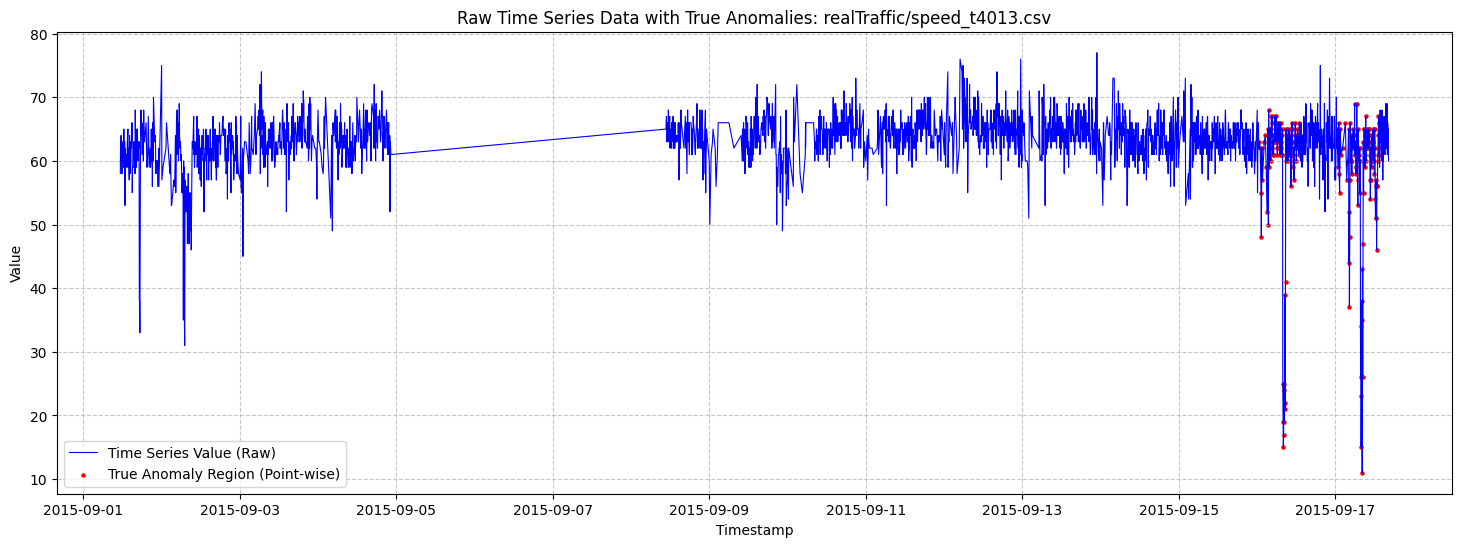

--- Data Loading and Label Processing Complete ---


In [148]:
# @title 1. NAB 数据加载与标签处理
# ------------------------------------------------------------------------------
# 用户指定参数：选择 NAB 数据集中的哪个文件进行处理
# ------------------------------------------------------------------------------
NAB_DATA_FILE_RELATIVE_PATH = 'realTraffic/speed_t4013.csv' # <--- 您选择的数据文件
# NAB_DATA_FILE_RELATIVE_PATH = 'realKnownCause/nyc_taxi.csv'
# NAB_DATA_FILE_RELATIVE_PATH = 'realAWSCloudwatch/ec2_cpu_utilization_ac20cd.csv'

DATA_FILE_COLAB_PATH = f'/content/NAB/data/{NAB_DATA_FILE_RELATIVE_PATH}'
LABEL_FILE_COLAB_PATH = '/content/NAB/labels/combined_windows.json'
JSON_KEY_FOR_LABELS = NAB_DATA_FILE_RELATIVE_PATH

print(f"--- Data Loading and Label Processing (NAB Dataset) ---")
print(f"Attempting to load data for: {NAB_DATA_FILE_RELATIVE_PATH}")

data_df = None # 初始化 data_df
raw_time_series_values = None # 将在此模块的末尾从 data_df['value'] 赋值
pointwise_true_labels = None # 将在此模块的末尾从 data_df['is_anomaly_pointwise'] 赋值

if not os.path.exists(DATA_FILE_COLAB_PATH):
    print(f"ERROR: Data file not found: {DATA_FILE_COLAB_PATH}")
    print(f"Please ensure the relative path '{NAB_DATA_FILE_RELATIVE_PATH}' is correct and the file exists in '/content/NAB/data/'.")
    print(f"Available top-level directories in /content/NAB/data/: {os.listdir('/content/NAB/data/')}")
else:
    try:
        data_df_loaded = pd.read_csv(DATA_FILE_COLAB_PATH) # 先加载到临时变量
        print(f"Successfully loaded data from: {DATA_FILE_COLAB_PATH}")
        print(f"Initial data shape: {data_df_loaded.shape}")
        print(f"Data columns: {data_df_loaded.columns.tolist()}")

        if 'timestamp' not in data_df_loaded.columns:
            raise ValueError("Column 'timestamp' not found in the CSV file.")
        data_df_loaded['timestamp'] = pd.to_datetime(data_df_loaded['timestamp'])
        data_df_loaded = data_df_loaded.set_index('timestamp')
        print("Timestamp column processed and set as DatetimeIndex.")

        if 'value' not in data_df_loaded.columns:
            raise ValueError("Column 'value' not found in the CSV file. Please ensure your data has a 'value' column for the time series readings.")

        data_df = data_df_loaded.copy() # 成功加载和初步处理后再赋给 data_df

    except Exception as e:
        print(f"Error during data loading or initial timestamp processing: {e}")
        data_df = None

if data_df is not None and 'value' in data_df.columns:
    data_df['is_anomaly_pointwise'] = 0
    parsed_anomaly_windows_count = 0

    if not os.path.exists(LABEL_FILE_COLAB_PATH):
        print(f"WARNING: Label file not found: {LABEL_FILE_COLAB_PATH}. Proceeding without anomaly labels.")
    else:
        try:
            with open(LABEL_FILE_COLAB_PATH, 'r') as f:
                all_labels_json = json.load(f)
            raw_anomaly_windows_list = all_labels_json.get(JSON_KEY_FOR_LABELS, [])

            if not raw_anomaly_windows_list:
                print(f"No anomaly windows found for key '{JSON_KEY_FOR_LABELS}'.")
            else:
                print(f"Found {len(raw_anomaly_windows_list)} raw anomaly window(s) for '{JSON_KEY_FOR_LABELS}'.")
                for window_event in raw_anomaly_windows_list:
                    if isinstance(window_event, list) and len(window_event) == 2:
                        try:
                            start_ts_str, end_ts_str = window_event
                            start_ts = pd.to_datetime(start_ts_str, errors='coerce')
                            end_ts = pd.to_datetime(end_ts_str, errors='coerce')
                            if pd.isna(start_ts) or pd.isna(end_ts):
                                 raise ValueError(f"Failed to parse timestamps: {start_ts_str}, {end_ts_str}")

                            anomalous_points_mask = (data_df.index >= start_ts) & (data_df.index <= end_ts)
                            data_df.loc[anomalous_points_mask, 'is_anomaly_pointwise'] = 1
                            if anomalous_points_mask.sum() > 0:
                                parsed_anomaly_windows_count += 1
                        except Exception as e_win:
                            print(f"  Warning: Could not process window event {window_event} for labeling: {e_win}")
                print(f"Label processing complete. Processed {parsed_anomaly_windows_count} anomaly window(s).")
                print(f"Total data points marked as anomalous in data_df: {data_df['is_anomaly_pointwise'].sum()}")
        except Exception as e_label:
            print(f"An error occurred during label processing: {e_label}")

    # 准备原始时间序列值和逐点真实标签 (现在从 data_df 获取)
    raw_time_series_values = data_df['value'].values.copy() # 使用 .copy() 避免后续修改影响原始 data_df
    pointwise_true_labels = data_df['is_anomaly_pointwise'].values.copy()

    print(f"\nPrepared 'raw_time_series_values' (shape: {raw_time_series_values.shape}).")
    print(f"Prepared 'pointwise_true_labels' (total anomalies: {pointwise_true_labels.sum()}).")

    plt.figure(figsize=(18, 6))
    plt.plot(data_df.index, data_df['value'], label='Time Series Value (Raw)', color='blue', linewidth=0.8)
    anomalous_data_plot = data_df[data_df['is_anomaly_pointwise'] == 1]
    if not anomalous_data_plot.empty:
        plt.scatter(anomalous_data_plot.index, anomalous_data_plot['value'], color='red', label='True Anomaly Region (Point-wise)', marker='.', s=20)
    plt.title(f"Raw Time Series Data with True Anomalies: {JSON_KEY_FOR_LABELS}")
    plt.xlabel("Timestamp")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

elif data_df is not None and 'value' not in data_df.columns:
    print("ERROR: 'value' column is missing from the loaded DataFrame. Cannot proceed.")
else:
    print("data_df was not loaded successfully. Cannot proceed with data preparation.")

print(f"--- Data Loading and Label Processing Complete ---")


--- Seasonal Decomposition ---
Seasonal decomposition complete using period=60.


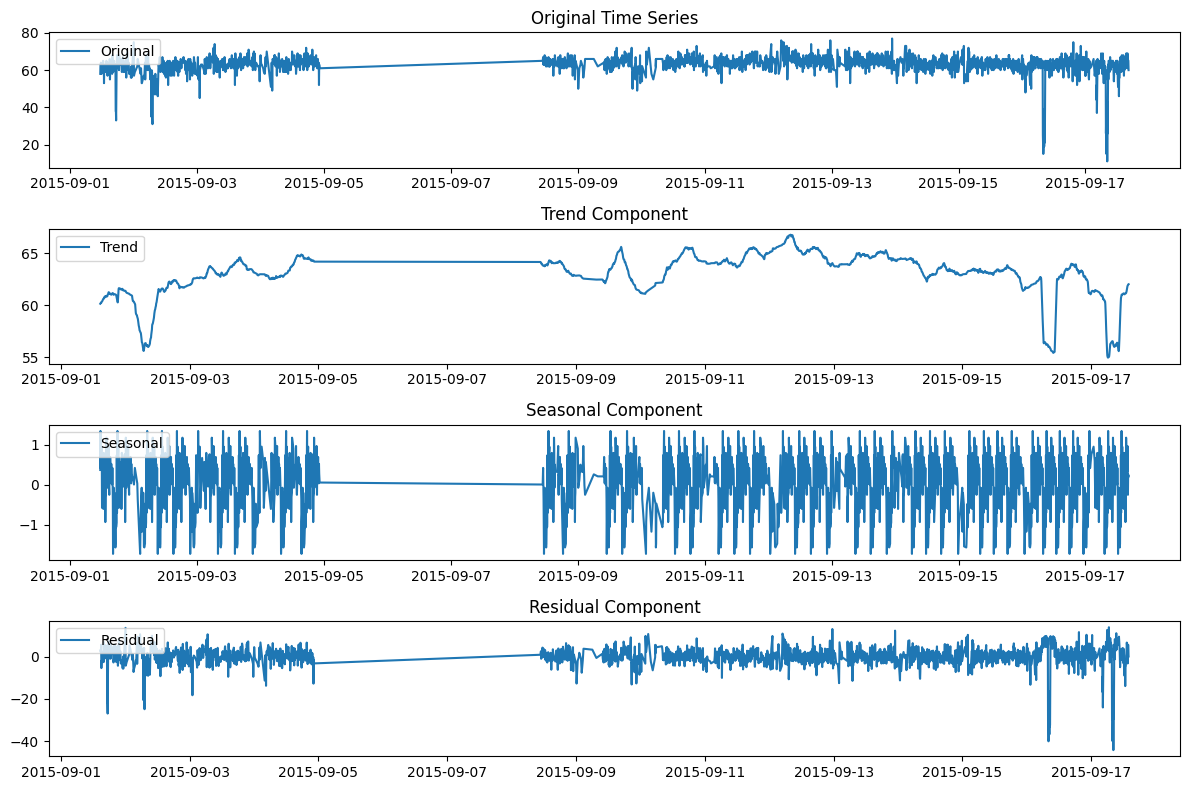

--- Seasonal Decomposition Complete ---


In [149]:
# @title 2. 季节性分解
# ------------------------------------------------------------------------------
# 对加载的时间序列数据 (data_df['value']) 进行季节性分解
# ------------------------------------------------------------------------------
print(f"\n--- Seasonal Decomposition ---")

decomposition = None
trend_component = None
seasonal_component = None
residual_component = None

if data_df is not None and 'value' in data_df.columns and not data_df['value'].isnull().all():
    # 确保 'value' 列是数值类型，并且至少有一些非 NaN 值才能进行分解
    if not pd.api.types.is_numeric_dtype(data_df['value']):
        print(f"Warning: 'value' column is not numeric. Attempting to convert...")
        try:
            data_df['value'] = pd.to_numeric(data_df['value'], errors='coerce')
            if data_df['value'].isnull().all():
                 raise ValueError("All values in 'value' column became NaN after conversion to numeric.")
        except Exception as e_conv:
            print(f"Error converting 'value' to numeric: {e_conv}. Skipping decomposition.")
            data_df = None # Mark as unusable for further steps

    if data_df is not None: # Re-check after potential conversion failure
        # 参数设置
        # period: 季节性的周期。例如，对于每小时数据，日季节性 period=24。
        #         对于5分钟数据，日季节性 period=24*12=288。
        #         您需要根据数据的采样频率和预期的季节性模式来设置。
        #         示例中使用 60，请根据您的具体数据调整。
        #         如果数据点少于 2 * period，seasonal_decompose 会报错。
        SEASONAL_PERIOD = 60 # <--- 关键参数！请根据您的数据特性调整
        MIN_OBS_FOR_DECOMP = 2 * SEASONAL_PERIOD

        if len(data_df['value'].dropna()) >= MIN_OBS_FOR_DECOMP:
            try:
                # model: 'additive' 或 'multiplicative'
                decomposition = seasonal_decompose(data_df['value'].dropna(), # 使用 dropna() 避免因数据开头结尾的 NaN 导致问题
                                                 model='additive',    # 或 'multiplicative'
                                                 period=SEASONAL_PERIOD)

                trend_component = decomposition.trend
                seasonal_component = decomposition.seasonal
                residual_component = decomposition.resid

                print(f"Seasonal decomposition complete using period={SEASONAL_PERIOD}.")

                # 可视化分解结果
                plt.figure(figsize=(12, 8))
                plt.subplot(411)
                plt.plot(data_df.index, data_df['value'], label='Original')
                plt.legend(loc='upper left')
                plt.title('Original Time Series')

                plt.subplot(412)
                plt.plot(trend_component, label='Trend')
                plt.legend(loc='upper left')
                plt.title('Trend Component')

                plt.subplot(413)
                plt.plot(seasonal_component, label='Seasonal')
                plt.legend(loc='upper left')
                plt.title('Seasonal Component')

                plt.subplot(414)
                plt.plot(residual_component, label='Residual')
                plt.legend(loc='upper left')
                plt.title('Residual Component')

                plt.tight_layout()
                plt.show()

            except ValueError as e_decomp:
                print(f"Error during seasonal decomposition: {e_decomp}")
                print(f"This might be due to insufficient data points (need at least {MIN_OBS_FOR_DECOMP} for period {SEASONAL_PERIOD}), or all NaN values.")
                decomposition = None # Ensure it's None if failed
            except Exception as e:
                print(f"An unexpected error occurred during seasonal decomposition: {e}")
                decomposition = None # Ensure it's None if failed
        else:
            print(f"Skipping seasonal decomposition: Not enough data points (have {len(data_df['value'].dropna())}, need at least {MIN_OBS_FOR_DECOMP}) for period {SEASONAL_PERIOD}.")
            decomposition = None
else:
    print("Skipping seasonal decomposition: data_df is not available, 'value' column is missing, or all values are NaN.")

print(f"--- Seasonal Decomposition Complete ---")


--- Kalman Filter & RTS Smoothing ---
Applying Kalman Filter and RTS Smoother to the residual component...
  Residual component length: 2495
  Number of NaNs in residual component before smoothing: 60
Kalman smoothing of residual component complete.
  Smoothed residual length: 2495
  Number of NaNs in smoothed residual: 0


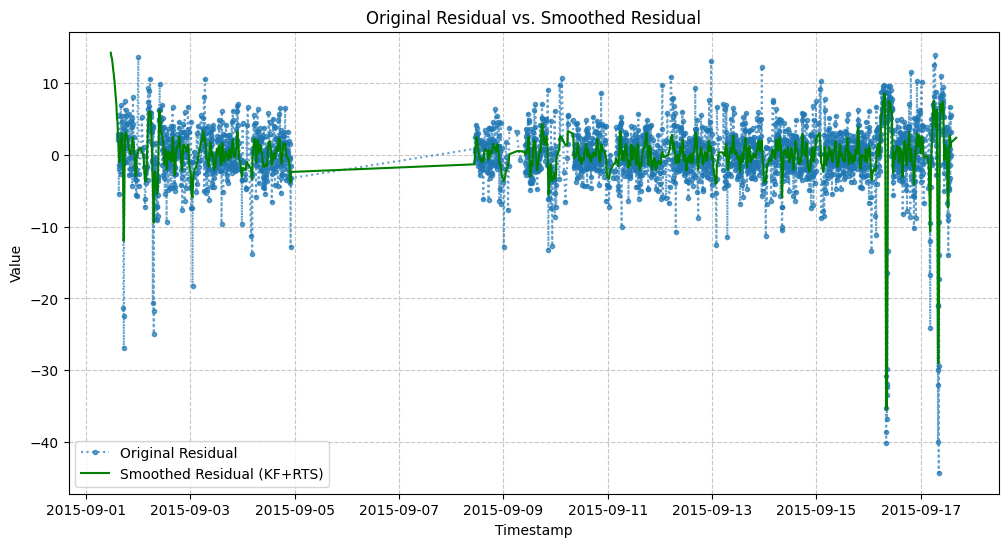

Smoothed residual component joined to data_df.
--- Kalman Filter & RTS Smoothing on Residual Component Complete ---


In [150]:
# @title 3. 卡尔曼滤波与 RTS 平滑器 (应用于残差分量)
# ------------------------------------------------------------------------------
# 定义 KF + RTS 平滑函数 (源自您的代码)
# ------------------------------------------------------------------------------
print(f"\n--- Kalman Filter & RTS Smoothing ---")

def kf_rts_fill(
        ts_values: np.ndarray,
        timestamps_unix: np.ndarray, # 期望是 UNIX 时间戳 (秒)
        freq: str = "1min",      # 重采样频率
        Q: float = 1e-5,         # 过程噪声协方差
        R: float = 1e-2,         # 测量噪声协方差
        init_var: float = 10.0   # 初始状态协方差
) -> pd.DataFrame:
    """
    KF + RTS smoothing with automatic resampling, gap-filling and denoising.
    Expects timestamps_unix as UNIX timestamps (seconds since epoch).
    Returns a DataFrame with 'timestamp' (original DatetimeIndex) and 'value_smoothed'.
    """
    if ts_values is None or timestamps_unix is None:
        print("kf_rts_fill: ts_values or timestamps_unix is None. Cannot proceed.")
        return pd.DataFrame(columns=['timestamp', 'value_smoothed'])
    if len(ts_values) == 0 or len(timestamps_unix) == 0:
        print("kf_rts_fill: ts_values or timestamps_unix is empty. Cannot proceed.")
        return pd.DataFrame(columns=['timestamp', 'value_smoothed'])
    if len(ts_values) != len(timestamps_unix):
        print(f"kf_rts_fill: Mismatch in lengths of ts_values ({len(ts_values)}) and timestamps_unix ({len(timestamps_unix)}). Cannot proceed.")
        # 为了安全，返回空 DataFrame，或者尝试对齐（但这里选择更安全的方式）
        return pd.DataFrame(columns=['timestamp', 'value_smoothed'])


    # 确保 ts_values 是一个 NumPy 数组
    ts_values_np = np.asarray(ts_values, dtype=float)

    # 创建一个以原始时间戳为索引的 DataFrame 用于对齐和平滑
    # 注意：kf_rts_fill 内部会根据 freq 进行重采样，但最终结果我们会尝试对齐回原始时间戳
    original_datetime_index = pd.to_datetime(timestamps_unix, unit='s')
    df_for_smoothing = pd.DataFrame({'value_raw': ts_values_np}, index=original_datetime_index)

    # 准备传递给内部处理的 z 值 (可能包含 NaN)
    # 内部的 resample(freq).mean() 会处理时间戳的对齐和聚合
    # 但这里我们要注意，如果原始数据点非常稀疏，重采样可能会引入更多NaN
    # 所以直接使用原始数据点和时间戳，让 filterpy 处理
    z = ts_values_np # 使用原始值，包含 NaN
    mask_obs = ~np.isnan(z)

    if not np.any(mask_obs): # 如果所有值都是 NaN
        print("kf_rts_fill: All ts_values are NaN. Returning original NaNs.")
        return pd.DataFrame({'timestamp': original_datetime_index, 'value_smoothed': ts_values_np})

    # 常速模型 Kalman Filter
    kf = KalmanFilter(dim_x=2, dim_z=1) # 状态: [位置, 速度], 观测: 位置
    kf.F = np.array([[1., 1.],  # 状态转移矩阵 F: x_k = F * x_{k-1}
                     [0., 1.]]) # position_k = position_{k-1} + velocity_{k-1}*dt (dt=1 here due to resampling)
                                # velocity_k = velocity_{k-1}
    kf.H = np.array([[1., 0.]]) # 观测函数 H: z_k = H * x_k (我们只观测位置)
    kf.Q = np.array([[Q/3, Q/2], # 过程噪声协方差 Q (更精确的离散化形式 for dt=1)
                     [Q/2, Q  ]]) * 1.0 # 假设 dt=1 (因为我们是逐点处理，或已重采样)
                                     # 如果有明确的 dt, Q 应与 dt 相关:
                                     # [[dt^3/3, dt^2/2], [dt^2/2, dt]] * process_noise_variance
    kf.R = np.array([[R]])      # 测量噪声协方差 R

    # 初始化状态和协方差
    # 尝试找到第一个非 NaN 值来初始化状态
    first_valid_index = np.where(mask_obs)[0]
    if len(first_valid_index) > 0:
        first_val = z[first_valid_index[0]]
    else: # 理论上不应该到这里，因为上面有 all NaN 检查
        first_val = 0.0
        print("kf_rts_fill: Warning - could not find a valid first value for KF initialization, using 0.")


    kf.x = np.array([[first_val], [0.]]) # 初始状态: [观测到的第一个值, 速度为0]
    kf.P = np.eye(2) * init_var          # 初始状态协方差矩阵 P

    means, covs = [], []

    # 卡尔曼滤波步骤
    for k_idx, zk_val in enumerate(z):
        kf.predict()
        if mask_obs[k_idx]: # 只有当观测值非NaN时才进行更新
            kf.update(np.array([[zk_val]]))
        means.append(kf.x.copy()) # 使用 .copy()
        covs.append(kf.P.copy())  # 使用 .copy()

    # 转换为 NumPy 数组以供 RTS 平滑器使用
    means_arr = np.array(means).reshape(-1, kf.dim_x) # 确保正确的形状 (N, dim_x)
    covs_arr = np.array(covs)                         # 形状 (N, dim_x, dim_x)

    # RTS 平滑
    # 检查 means_arr 和 covs_arr 是否为空
    if means_arr.shape[0] == 0:
        print("kf_rts_fill: No means were generated by Kalman filter (possibly all NaNs or empty input). Returning NaNs.")
        return pd.DataFrame({'timestamp': original_datetime_index, 'value_smoothed': np.full_like(ts_values_np, np.nan)})


    xs_smoothed, Ps_smoothed, _, _ = kf.rts_smoother(means_arr, covs_arr)

    # 创建结果 DataFrame，索引与原始输入 DataFrame 对齐
    result_df = pd.DataFrame({
        'timestamp': original_datetime_index,
        'value_smoothed': xs_smoothed[:, 0] # 只取平滑后的位置分量
    }).set_index('timestamp')

    return result_df

# ------------------------------------------------------------------------------
# 应用 KF + RTS 到残差分量
# ------------------------------------------------------------------------------
df_residual_smoothed = None
residual_smoothed_values = None # 将持有平滑后的残差值

# 假设 residual_component 已经从 seasonal_decompose 中获取
# residual_component = decomposition.resid (其中 decomposition 是 seasonal_decompose 的结果)

if residual_component is not None and not residual_component.empty:
    # 准备卡尔曼滤波的输入
    # 残差分量可能在开头和结尾有 NaN，kf_rts_fill 函数应该能处理
    residual_values_for_kf = residual_component.values
    residual_timestamps_unix_for_kf = residual_component.index.astype(np.int64) // 10**9 # 转换为 UNIX 秒

    print(f"Applying Kalman Filter and RTS Smoother to the residual component...")
    print(f"  Residual component length: {len(residual_values_for_kf)}")
    print(f"  Number of NaNs in residual component before smoothing: {np.isnan(residual_values_for_kf).sum()}")

    # 调用平滑函数
    # !! 注意：对于残差分量，Q 和 R 的最佳值可能与趋势分量不同 !!
    # 残差通常更像噪声。你可能需要：
    # - 更大的 R：如果认为观测到的残差本身包含很多随机噪声。
    # - 适当的 Q：如果认为残差的真实"信号"部分随时间缓慢变化。
    #   如果残差理论上是白噪声，平滑可能效果不佳或不是主要目的。
    #   如果目标是去除一些异常波动，可以尝试。
    df_residual_smoothed_results = kf_rts_fill(
        ts_values=residual_values_for_kf,
        timestamps_unix=residual_timestamps_unix_for_kf,
        # freq="5min", # 根据你的数据频率调整或移除
        Q=1e-4,       # 过程噪声，根据残差特性调整
        R=1e-3,       # 测量噪声，根据残差特性调整
        init_var=1.0  # 初始不确定性
    )

    if not df_residual_smoothed_results.empty:
        df_residual_smoothed = df_residual_smoothed_results.rename(columns={'value_smoothed': 'residual_smoothed'})
        residual_smoothed_values = df_residual_smoothed['residual_smoothed'].values

        print(f"Kalman smoothing of residual component complete.")
        print(f"  Smoothed residual length: {len(residual_smoothed_values)}")
        print(f"  Number of NaNs in smoothed residual: {np.isnan(residual_smoothed_values).sum()}")

        # 可视化原始残差和平滑后的残差
        plt.figure(figsize=(12, 6))
        plt.plot(residual_component.index, residual_component.values, label='Original Residual', alpha=0.7, linestyle=':', marker='.')
        if df_residual_smoothed is not None and not df_residual_smoothed.empty:
            plt.plot(df_residual_smoothed.index, df_residual_smoothed['residual_smoothed'], label='Smoothed Residual (KF+RTS)', color='green')
        plt.title('Original Residual vs. Smoothed Residual')
        plt.xlabel('Timestamp')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

        # 更新 data_df (可选)
        # 注意：如何使用平滑后的残差取决于你的具体目标。
        # 通常，平滑残差的目的是分析其结构或去除极端异常值。
        # 如果要重构信号，通常是用原始残差或处理后的残差。
        if data_df is not None and df_residual_smoothed is not None:
            data_df = data_df.join(df_residual_smoothed) # 将平滑后的残差加入
            # 你可能还想保留原始残差
            if 'resid' not in data_df.columns and residual_component is not None: # 假设原始残差列名为 resid
                 data_df = data_df.join(residual_component.rename('resid'))

            # 如果分解是加法模型: original_signal = trend + seasonal + residual
            # 如果你想用平滑后的残差重构信号:
            # reconstructed_signal = trend_component + seasonal_component + df_residual_smoothed['residual_smoothed']
            # 这需要你有 trend_component 和 seasonal_component
            print("Smoothed residual component joined to data_df.")

    else:
        print("Kalman smoothing of residual component resulted in empty DataFrame.")
        residual_smoothed_values = residual_component.values # 回退到原始残差（可能含NaN）

elif residual_component is not None and residual_component.empty:
    print("Residual component is empty. Skipping Kalman smoothing.")
    residual_smoothed_values = np.array([]) # 空数组
else:
    print("Residual component is not available. Skipping Kalman smoothing.")
    residual_smoothed_values = None # 标记为不可用

print(f"--- Kalman Filter & RTS Smoothing on Residual Component Complete ---")

In [151]:
# @title 4. 数据准备 (缩放、窗口化、窗口级别标签 - 基于预处理数据)
# ------------------------------------------------------------------------------
# 注意：这里将使用前面步骤预处理后的数据 (例如，平滑后的趋势分量)
# 或者，如果预处理步骤失败/跳过，则回退到原始数据。
# ------------------------------------------------------------------------------
print(f"\n--- Data Preparation for TimesNet (Scaling, Windowing, Window-Level Labels on Preprocessed Data) ---")
X_tensor = None
dataloader = None
window_level_true_labels_for_model = None # 窗口标签，基于原始 pointwise_true_labels
WINDOW_SIZE = None
time_series_for_model_scaled = None
X_windowed_data_np = None
input_series_for_timesnet = None # 这是将要被缩放和窗口化的序列

# 决定使用哪个时间序列进行 TimesNet 输入
if residual_smoothed_values is not None and len(residual_smoothed_values) > 0:
    # 检查 residual_smoothed_values 是否有很多 NaN
    # 卡尔曼滤波应该已经填充了 NaN，但以防万一
    if np.isnan(residual_smoothed_values).all():
        print("Warning: Smoothed trend is all NaN. Falling back to raw data for TimesNet.")
        input_series_for_timesnet = raw_time_series_values # 原始数据也可能含NaN
    else:
        # 如果平滑趋势中有NaN (理论上 KF+RTS 应该填补了大部分), 需要处理
        # 一个简单的策略是向前填充，然后向后填充
        temp_series_pd = pd.Series(residual_smoothed_values)
        temp_series_pd.ffill(inplace=True)
        temp_series_pd.bfill(inplace=True)
        input_series_for_timesnet = temp_series_pd.values
        print("Using smoothed trend component (after ffill/bfill) as input for TimesNet.")
        # 确保是一维的
        if input_series_for_timesnet.ndim > 1 and input_series_for_timesnet.shape[1] == 1:
            input_series_for_timesnet = input_series_for_timesnet.flatten()
        elif input_series_for_timesnet.ndim > 1:
            print(f"Error: Smoothed trend has more than 1 feature dimension ({input_series_for_timesnet.shape}). Cannot directly use for univariate TimesNet.")
            input_series_for_timesnet = None # 标记为不可用


elif raw_time_series_values is not None and len(raw_time_series_values) > 0:
    print("Smoothed trend is not available or empty. Using raw time series values for TimesNet.")
    # 原始数据也可能包含NaN，需要处理
    temp_series_pd = pd.Series(raw_time_series_values.flatten()) # 确保一维
    temp_series_pd.ffill(inplace=True)
    temp_series_pd.bfill(inplace=True)
    # 如果填充后仍然有NaN (例如序列全为NaN)，则用0填充
    if temp_series_pd.isnull().any():
        print("Warning: Raw data still contains NaNs after ffill/bfill. Filling remaining NaNs with 0.")
        temp_series_pd.fillna(0, inplace=True)
    input_series_for_timesnet = temp_series_pd.values
else:
    print("ERROR: Neither smoothed trend nor raw time series is available. Cannot proceed with TimesNet data preparation.")
    input_series_for_timesnet = None

# 确保 input_series_for_timesnet 是 (N,) 或 (N,1) 的形状
if input_series_for_timesnet is not None and input_series_for_timesnet.ndim == 1:
    input_series_for_timesnet = input_series_for_timesnet.reshape(-1, 1)


# 确保 pointwise_true_labels 与 input_series_for_timesnet 的长度一致
# 季节性分解和卡尔曼滤波可能会改变序列的长度（例如，如果原始数据有NaN被dropna，或者KF输出长度不一致）
# 通常，我们希望 pointwise_true_labels 与 data_df 的原始长度对齐。
# 而 input_series_for_timesnet (如平滑趋势) 也应该通过索引与 data_df 对齐。
# 这里假设 pointwise_true_labels 保持其原始长度，与 data_df.index 对齐。
# 如果 input_series_for_timesnet 的长度由于处理（例如，趋势组件两端的 NaN 被移除再由KF插值回来）
# 与 pointwise_true_labels 不同，我们需要小心。
# 最安全的做法是确保 input_series_for_timesnet 的长度与 data_df.index 匹配，
# 这样 pointwise_true_labels 也能正确对齐。
# kf_rts_fill 返回的 DataFrame 应该与原始时间戳对齐。

# 检查长度是否一致，如果不一致，这是一个严重的问题
if (input_series_for_timesnet is not None and
    pointwise_true_labels is not None and
    len(input_series_for_timesnet) != len(pointwise_true_labels)):
    print(f"WARNING: Length mismatch between input_series_for_timesnet ({len(input_series_for_timesnet)}) "
          f"and pointwise_true_labels ({len(pointwise_true_labels)}). This can lead to incorrect label mapping for windows.")
    print("Attempting to reconcile lengths by taking the minimum length. THIS IS A RISKY OPERATION.")
    min_len = min(len(input_series_for_timesnet), len(pointwise_true_labels))
    input_series_for_timesnet = input_series_for_timesnet[:min_len]
    pointwise_true_labels = pointwise_true_labels[:min_len]
    if data_df is not None and len(data_df) > min_len: # 如果 data_df 存在且更长，也截断它以保持一致性
        data_df = data_df.iloc[:min_len]


if input_series_for_timesnet is not None and len(input_series_for_timesnet) > 0 and pointwise_true_labels is not None:
    scaler = MinMaxScaler(feature_range=(0, 1))
    time_series_for_model_scaled = scaler.fit_transform(input_series_for_timesnet) # 应该是 (N, 1)
    print(f"Input data for TimesNet scaled. Shape: {time_series_for_model_scaled.shape}")

    WINDOW_SIZE = 96 # 保持与temp.py一致，可调整
    print(f"Using WINDOW_SIZE (seq_len for TimesNet): {WINDOW_SIZE}")

    if len(time_series_for_model_scaled) < WINDOW_SIZE:
        print(f"ERROR: Data length ({len(time_series_for_model_scaled)}) is less than WINDOW_SIZE ({WINDOW_SIZE}). Cannot create windows.")
    else:
        def create_windows_for_timesnet(input_data, window_length):
            windows = []
            for i in range(len(input_data) - window_length + 1):
                window = input_data[i : i + window_length]
                windows.append(window)
            return np.array(windows)

        X_windowed_data_np = create_windows_for_timesnet(time_series_for_model_scaled, WINDOW_SIZE) # Shape (N_windows, WINDOW_SIZE, N_features=1)

        if X_windowed_data_np.shape[0] > 0:
            print(f"Created windows. Shape: {X_windowed_data_np.shape}")

            X_tensor = torch.tensor(X_windowed_data_np, dtype=torch.float32).to(device)
            y_tensor_target = X_tensor.detach().clone() # 重构任务
            print(f"X_tensor shape: {X_tensor.shape}, y_tensor_target shape: {y_tensor_target.shape}")

            # 创建窗口级别的真实标签 (使用原始的 pointwise_true_labels)
            num_windows = X_windowed_data_np.shape[0]
            temp_window_labels = []
            # 确保 pointwise_true_labels 至少与能形成窗口的数据点一样长
            if len(pointwise_true_labels) >= WINDOW_SIZE:
                for i in range(num_windows):
                    # 窗口 i 对应于原始 pointwise_true_labels 的 [i : i + WINDOW_SIZE] 部分
                    if i + WINDOW_SIZE <= len(pointwise_true_labels):
                        original_points_in_window_labels = pointwise_true_labels[i : i + WINDOW_SIZE]
                        is_window_anomalous = np.any(original_points_in_window_labels == 1)
                        temp_window_labels.append(1 if is_window_anomalous else 0)
                    else: # 应该不会发生，因为 num_windows 是基于可形成窗口的数量
                        temp_window_labels.append(0) # 安全回退
                window_level_true_labels_for_model = np.array(temp_window_labels)
                print(f"Created window-level true labels. Shape: {window_level_true_labels_for_model.shape}, Anomalous windows: {window_level_true_labels_for_model.sum()}")
            else:
                print(f"Warning: pointwise_true_labels length ({len(pointwise_true_labels)}) is too short to create window labels with WINDOW_SIZE {WINDOW_SIZE}.")
                window_level_true_labels_for_model = np.zeros(num_windows, dtype=int) # 全为0作为回退


            BATCH_SIZE_MODEL = 32
            dataset = TensorDataset(X_tensor, y_tensor_target)
            dataloader = DataLoader(dataset, batch_size=BATCH_SIZE_MODEL, shuffle=True)
            print(f"DataLoader created with batch size {BATCH_SIZE_MODEL}.")
        else:
            print("No windows were created. Cannot proceed with TimesNet.")
else:
    print("Skipping TimesNet data preparation as input series or pointwise labels are not available/valid.")

print(f"--- Data Preparation for TimesNet Complete ---")


--- Data Preparation for TimesNet (Scaling, Windowing, Window-Level Labels on Preprocessed Data) ---
Using smoothed trend component (after ffill/bfill) as input for TimesNet.
Input data for TimesNet scaled. Shape: (2495, 1)
Using WINDOW_SIZE (seq_len for TimesNet): 96
Created windows. Shape: (2400, 96, 1)
X_tensor shape: torch.Size([2400, 96, 1]), y_tensor_target shape: torch.Size([2400, 96, 1])
Created window-level true labels. Shape: (2400,), Anomalous windows: 380
DataLoader created with batch size 32.
--- Data Preparation for TimesNet Complete ---


In [152]:
# @title 5. TimesNet 模型定义
# ------------------------------------------------------------------------------
# TimesNet 模型需要一个配置对象或一系列参数。
# ------------------------------------------------------------------------------
print(f"\n--- TimesNet Model Definition ---")

model = None # Initialize model variable

# 确保 WINDOW_SIZE 和 X_tensor 从模块 4 传递过来并且有效
if WINDOW_SIZE is not None and X_tensor is not None and X_tensor.nelement() > 0 : # 检查 X_tensor 是否非空
    class TimesNetConfigs:
        def __init__(self, current_window_size, num_features=1): # num_features 默认为1
            self.seq_len = current_window_size
            self.pred_len = 0
            self.enc_in = num_features
            self.c_out = num_features
            self.d_model = 64
            self.d_ff = 64
            self.num_kernels = 6
            self.e_layers = 2
            self.top_k = 5
            self.dropout = 0.1
            self.task_name = 'anomaly_detection'
            self.embed = 'fixed'
            self.freq = 'h' # 对于embed='fixed', 此参数影响不大
            self.output_attention = False
            self.label_len = 0

    try:
        # n_features 应该是1，因为我们处理的是单变量序列
        n_features_model = X_tensor.shape[2] if X_tensor.ndim == 3 else 1
        if n_features_model != 1:
            print(f"Warning: Expected n_features=1 for TimesNet, but got {n_features_model} from X_tensor. Using n_features=1.")
            n_features_model = 1

        model_configs = TimesNetConfigs(WINDOW_SIZE, num_features=n_features_model)
        model = TimesNetModel(model_configs).float().to(device)
        print("TimesNet model instantiated.")
        # print(model)

        if list(model.parameters()):
            print(f"Model is on device: {next(model.parameters()).device}")
        else:
            print("Warning: Model has no parameters.")

    except Exception as e_model_init:
        print(f"ERROR instantiating TimesNet model: {e_model_init}")
        import traceback
        traceback.print_exc()
        model = None
else:
    print("Cannot instantiate TimesNet model: WINDOW_SIZE not set or X_tensor not available/empty (check Data Preparation step).")
    if WINDOW_SIZE is None: print("  Reason: WINDOW_SIZE is None.")
    if X_tensor is None: print("  Reason: X_tensor is None.")
    elif X_tensor.nelement() == 0: print("  Reason: X_tensor is empty.")


print(f"--- Model Definition Complete ---")


--- TimesNet Model Definition ---
TimesNet model instantiated.
Model is on device: cuda:0
--- Model Definition Complete ---



--- Model Training (TimesNet for Reconstruction) ---
Starting training TimesNet for 10 epochs with LR=0.001...
Epoch [1/10], Loss: 0.0006739
Epoch [2/10], Loss: 0.0000663
Epoch [3/10], Loss: 0.0000446
Epoch [4/10], Loss: 0.0000354
Epoch [5/10], Loss: 0.0000307
Epoch [6/10], Loss: 0.0000196
Epoch [7/10], Loss: 0.0000282
Epoch [8/10], Loss: 0.0000418
Epoch [9/10], Loss: 0.0000304
Epoch [10/10], Loss: 0.0000134
Training finished.


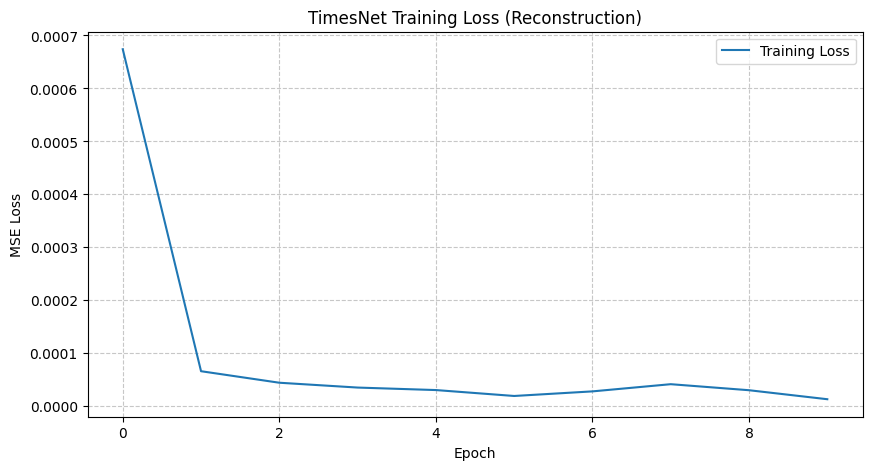

--- Model Training Complete ---


In [153]:
# @title 6. 模型训练 (TimesNet for Reconstruction)
# ------------------------------------------------------------------------------
# TimesNet 通过学习重构输入序列来进行异常检测。
# ------------------------------------------------------------------------------
print(f"\n--- Model Training (TimesNet for Reconstruction) ---")
history = {'train_loss': []}

if model is not None and dataloader is not None :
    NUM_EPOCHS_TIMESNET = 10 # 可调整
    LEARNING_RATE_TIMESNET = 0.001

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE_TIMESNET)

    print(f"Starting training TimesNet for {NUM_EPOCHS_TIMESNET} epochs with LR={LEARNING_RATE_TIMESNET}...")

    for epoch in range(NUM_EPOCHS_TIMESNET):
        model.train()
        epoch_loss = 0
        for batch_x, batch_y_true_reconstruction in dataloader:
            optimizer.zero_grad()
            dec_inp_dummy = torch.zeros_like(batch_x).float().to(device)
            outputs = model(batch_x, None, dec_inp_dummy, None)
            loss = criterion(outputs, batch_y_true_reconstruction)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(dataloader)
        history['train_loss'].append(avg_epoch_loss)
        if (epoch + 1) % 1 == 0 or epoch == NUM_EPOCHS_TIMESNET - 1 :
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS_TIMESNET}], Loss: {avg_epoch_loss:.7f}")
    print("Training finished.")

    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Training Loss')
    plt.title('TimesNet Training Loss (Reconstruction)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Skipping model training: model or dataloader is not available/valid.")
    if model is None: print("  Reason: model is None (check Model Definition step).")
    if dataloader is None: print("  Reason: dataloader is None (check Data Preparation step).")

print(f"--- Model Training Complete ---")


--- Anomaly Score Calculation (TimesNet Reconstruction Error) ---
Calculated anomaly scores for 2400 sequences using TimesNet reconstruction.
Anomaly scores (from TimesNet reconstruction) mapped to time points of the scaled input series.


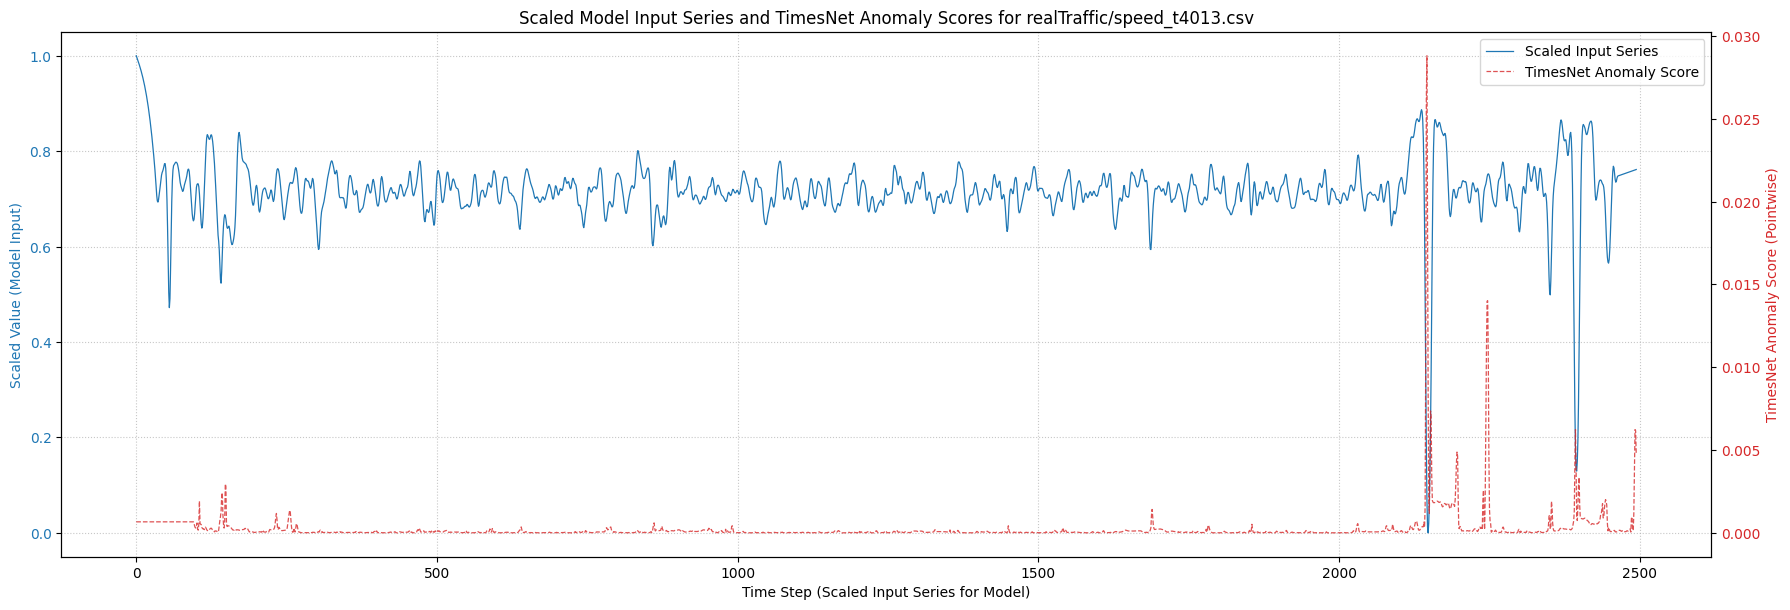

--- Anomaly Score Calculation (TimesNet) Complete ---


In [154]:
# @title 7. 异常分数计算 (TimesNet 重构误差)
# ------------------------------------------------------------------------------
# 使用训练好的模型对所有窗口进行重构，计算重构误差作为异常分数。
# ------------------------------------------------------------------------------
print(f"\n--- Anomaly Score Calculation (TimesNet Reconstruction Error) ---")
anomaly_scores_per_sequence = None
anomaly_scores_timesnet_pointwise = None

if (model is not None and
    X_tensor is not None and X_tensor.size(0) > 0 and # X_tensor 包含窗口化数据
    WINDOW_SIZE is not None and
    time_series_for_model_scaled is not None and len(time_series_for_model_scaled) > 0): # 这是缩放后的完整序列

    model.eval()
    temp_anomaly_scores_per_sequence = []
    eval_dataset_tsn = TensorDataset(X_tensor, X_tensor) # 使用模块4的 X_tensor
    eval_dataloader_tsn = DataLoader(eval_dataset_tsn, batch_size=BATCH_SIZE_MODEL, shuffle=False) # BATCH_SIZE_MODEL 来自模块4
    reconstruction_criterion_none = nn.MSELoss(reduction='none').to(device)

    with torch.no_grad():
        for batch_x, _ in eval_dataloader_tsn:
            dec_inp_dummy_eval = torch.zeros_like(batch_x).float().to(device)
            reconstruction = model(batch_x, None, dec_inp_dummy_eval, None)
            loss_pointwise = reconstruction_criterion_none(reconstruction, batch_x)
            loss_per_timestep = loss_pointwise.mean(dim=-1) # (BATCH_SIZE, WINDOW_SIZE)
            current_batch_anomaly_scores = loss_per_timestep.max(dim=-1)[0]
            temp_anomaly_scores_per_sequence.extend(current_batch_anomaly_scores.cpu().numpy())

    anomaly_scores_per_sequence = np.array(temp_anomaly_scores_per_sequence)
    print(f"Calculated anomaly scores for {len(anomaly_scores_per_sequence)} sequences using TimesNet reconstruction.")

    # 将序列异常分数映射回每个时间点 (与 time_series_for_model_scaled 对齐)
    anomaly_scores_timesnet_pointwise = np.full(len(time_series_for_model_scaled), np.nan)
    num_expected_sequences = len(time_series_for_model_scaled) - WINDOW_SIZE + 1

    if len(anomaly_scores_per_sequence) == num_expected_sequences:
        for i in range(len(anomaly_scores_per_sequence)):
            anomaly_scores_timesnet_pointwise[i + WINDOW_SIZE - 1] = anomaly_scores_per_sequence[i]
        first_valid_idx_pointwise = np.where(~np.isnan(anomaly_scores_timesnet_pointwise))[0]
        if len(first_valid_idx_pointwise) > 0:
            anomaly_scores_timesnet_pointwise[:first_valid_idx_pointwise[0]] = anomaly_scores_timesnet_pointwise[first_valid_idx_pointwise[0]]
        else:
            anomaly_scores_timesnet_pointwise[:] = 0 # Should not happen if scores were generated
        print("Anomaly scores (from TimesNet reconstruction) mapped to time points of the scaled input series.")
    elif len(anomaly_scores_per_sequence) > 0 :
        print(f"Warning: Length mismatch for TimesNet anomaly scores. Expected {num_expected_sequences}, got {len(anomaly_scores_per_sequence)}. Partial fill.")
        # (与原代码类似的填充逻辑)
        fill_len = min(len(anomaly_scores_per_sequence), num_expected_sequences)
        if fill_len > 0 :
            for i in range(fill_len):
                 anomaly_scores_timesnet_pointwise[i + WINDOW_SIZE - 1] = anomaly_scores_per_sequence[i]
            first_valid_idx_fill = np.where(~np.isnan(anomaly_scores_timesnet_pointwise))[0]
            if len(first_valid_idx_fill) > 0:
                anomaly_scores_timesnet_pointwise[:first_valid_idx_fill[0]] = anomaly_scores_timesnet_pointwise[first_valid_idx_fill[0]]
            else: anomaly_scores_timesnet_pointwise[:] = 0
        else: anomaly_scores_timesnet_pointwise[:] = 0
        print("Partial mapping of anomaly scores complete.")
    else: # No scores generated
        print("No anomaly scores were calculated by TimesNet. Filling pointwise scores with zeros.")
        anomaly_scores_timesnet_pointwise = np.zeros(len(time_series_for_model_scaled))


    if (time_series_for_model_scaled is not None and len(time_series_for_model_scaled) > 0 and
        anomaly_scores_timesnet_pointwise is not None and len(anomaly_scores_timesnet_pointwise) == len(time_series_for_model_scaled)):
        fig, ax1 = plt.subplots(figsize=(18, 6))
        color = 'tab:blue'
        ax1.set_xlabel('Time Step (Scaled Input Series for Model)')
        ax1.set_ylabel('Scaled Value (Model Input)', color=color)
        ax1.plot(time_series_for_model_scaled, color=color, label='Scaled Input Series', linewidth=0.9)
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.grid(True, linestyle=':', alpha=0.7)

        ax2 = ax1.twinx()
        color = 'tab:red'
        ax2.set_ylabel('TimesNet Anomaly Score (Pointwise)', color=color)
        ax2.plot(anomaly_scores_timesnet_pointwise, color=color, label='TimesNet Anomaly Score', linestyle='--', linewidth=0.9, alpha=0.8)
        ax2.tick_params(axis='y', labelcolor=color)

        fig.tight_layout()
        plt.title(f'Scaled Model Input Series and TimesNet Anomaly Scores for {NAB_DATA_FILE_RELATIVE_PATH}')
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='best')
        plt.show()
    else:
        print("Could not plot anomaly scores: data missing or mismatched lengths.")
        print(f"  Debug: time_series_for_model_scaled len: {len(time_series_for_model_scaled) if time_series_for_model_scaled is not None else 'None'}")
        print(f"  Debug: anomaly_scores_timesnet_pointwise len: {len(anomaly_scores_timesnet_pointwise) if anomaly_scores_timesnet_pointwise is not None else 'None'}")

else:
    print("Skipping TimesNet anomaly score calculation as model or data prerequisites are not met.")
    # (与原代码类似的调试信息)
    if model is None: print("  Reason: model is None.")
    if X_tensor is None or X_tensor.size(0) == 0: print("  Reason: X_tensor (windowed data) is None or empty.")
    if WINDOW_SIZE is None: print("  Reason: WINDOW_SIZE is None.")
    if time_series_for_model_scaled is None or len(time_series_for_model_scaled) == 0: print("  Reason: time_series_for_model_scaled (full scaled series for model) is None or empty.")

print(f"--- Anomaly Score Calculation (TimesNet) Complete ---")

In [155]:
# @title 8. 阈值设定与评估 (窗口级别 - TimesNet)
# ------------------------------------------------------------------------------
# 基于 anomaly_scores_per_sequence 和 window_level_true_labels_for_model
# ------------------------------------------------------------------------------
print(f"\n--- Thresholding and Evaluation (TimesNet on Window-Level) ---")
predicted_window_anomalies_bool_tsn = None # 初始化

if (anomaly_scores_per_sequence is not None and
    window_level_true_labels_for_model is not None and # 使用模块4生成的标签
    len(anomaly_scores_per_sequence) == len(window_level_true_labels_for_model) and
    len(window_level_true_labels_for_model) > 0 and
    WINDOW_SIZE is not None):

    threshold_percentile = 0.95
    if len(anomaly_scores_per_sequence) > 0:
        threshold_timesnet = np.quantile(anomaly_scores_per_sequence, threshold_percentile)
    else: # Should not happen if previous checks pass
        threshold_timesnet = 0

    print(f"Anomaly threshold (on TimesNet sequence scores, {threshold_percentile*100:.0f}th percentile): {threshold_timesnet:.6f}")

    predicted_window_anomalies_bool_tsn = anomaly_scores_per_sequence > threshold_timesnet
    predicted_window_anomalies_int_tsn = predicted_window_anomalies_bool_tsn.astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        window_level_true_labels_for_model, # 真实标签
        predicted_window_anomalies_int_tsn, # 预测标签
        average='binary',
        zero_division=0
    )
    cm = confusion_matrix(window_level_true_labels_for_model, predicted_window_anomalies_int_tsn)

    print(f"\nEvaluation Results (TimesNet, Window-Level for '{NAB_DATA_FILE_RELATIVE_PATH}'):")
    print(f"  Window size (seq_len) used: {WINDOW_SIZE}")
    print(f"  Number of windows evaluated: {len(window_level_true_labels_for_model)}")
    print(f"  True anomalous windows: {window_level_true_labels_for_model.sum()}")
    print(f"  Predicted anomalous windows: {predicted_window_anomalies_int_tsn.sum()}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Confusion Matrix (Window-Level):\n{cm}")
    if cm.size == 4:
      tn, fp, fn, tp = cm.ravel()
      print(f"    True Negatives (TN): {tn}, False Positives (FP): {fp}")
      print(f"    False Negatives (FN): {fn}, True Positives (TP): {tp}")
    else: # Handle cases with only one class in predictions or true labels
      print(f"    Confusion matrix shape {cm.shape} not 2x2, cannot unpack TN/FP/FN/TP.")


else:
    print("Skipping window-level evaluation for TimesNet due to missing prerequisites or data mismatch.")
    # (与原代码类似的调试信息)
    print(f"  Debug Info:")
    print(f"    anomaly_scores_per_sequence is None: {anomaly_scores_per_sequence is None}")
    if anomaly_scores_per_sequence is not None: print(f"    len(anomaly_scores_per_sequence): {len(anomaly_scores_per_sequence)}")
    print(f"    window_level_true_labels_for_model is None: {window_level_true_labels_for_model is None}")
    if window_level_true_labels_for_model is not None: print(f"    len(window_level_true_labels_for_model): {len(window_level_true_labels_for_model)}")
    if anomaly_scores_per_sequence is not None and window_level_true_labels_for_model is not None :
        print(f"    Length mismatch: {len(anomaly_scores_per_sequence)} vs {len(window_level_true_labels_for_model)}")
    print(f"    WINDOW_SIZE is None or invalid: {WINDOW_SIZE}")


print(f"--- Thresholding and Evaluation (TimesNet, Window-Level) Complete ---")


--- Thresholding and Evaluation (TimesNet on Window-Level) ---
Anomaly threshold (on TimesNet sequence scores, 95th percentile): 0.000867

Evaluation Results (TimesNet, Window-Level for 'realTraffic/speed_t4013.csv'):
  Window size (seq_len) used: 96
  Number of windows evaluated: 2400
  True anomalous windows: 380
  Predicted anomalous windows: 120
  Precision: 0.8583
  Recall:    0.2711
  F1-Score:  0.4120
  Confusion Matrix (Window-Level):
[[2003   17]
 [ 277  103]]
    True Negatives (TN): 2003, False Positives (FP): 17
    False Negatives (FN): 277, True Positives (TP): 103
--- Thresholding and Evaluation (TimesNet, Window-Level) Complete ---



--- Final Visualization (TimesNet on Raw Data with Detected Windows) ---


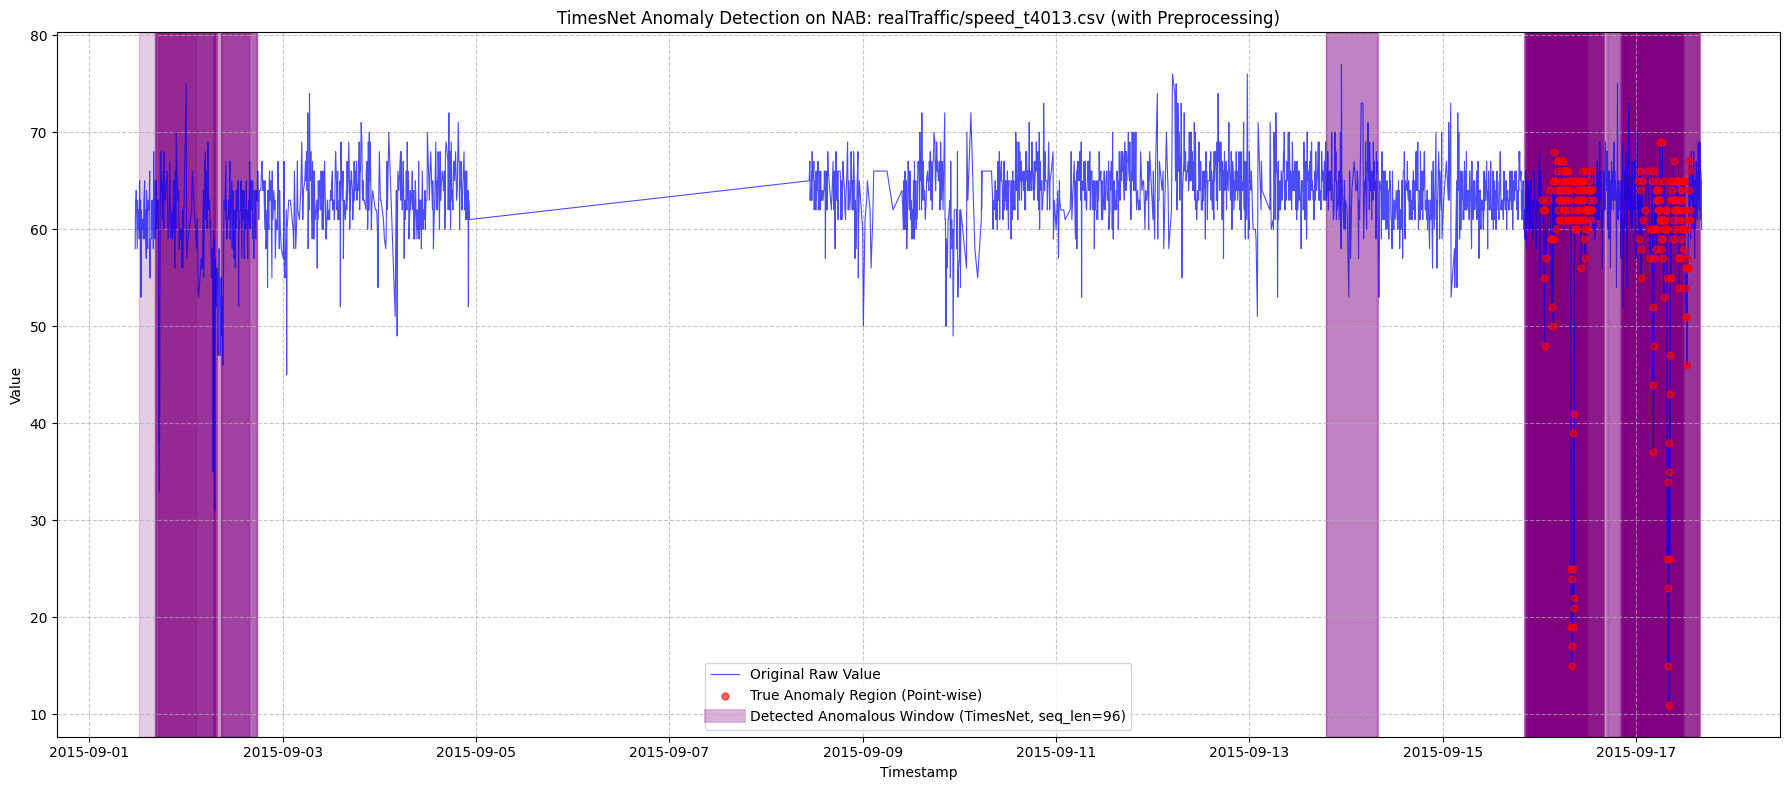

--- Visualization (TimesNet) Complete ---

--- End of Script (with Preprocessing) ---


In [156]:
# @title 9. 最终可视化 (原始数据上的异常窗口 - TimesNet)
# ------------------------------------------------------------------------------
# 在原始时间序列数据 (data_df['value']) 上展示真实的异常区域和TimesNet检测到的异常窗口。
# ------------------------------------------------------------------------------
print(f"\n--- Final Visualization (TimesNet on Raw Data with Detected Windows) ---")

# 确保所有必要的数据都已准备好
if (data_df is not None and not data_df.empty and 'value' in data_df.columns and # 原始数据 DataFrame (从模块1/3更新)
    WINDOW_SIZE is not None and                                              # 窗口大小 (从模块4)
    predicted_window_anomalies_bool_tsn is not None and                      # TimesNet的窗口预测结果 (从模块8)
    X_windowed_data_np is not None and X_windowed_data_np.shape[0] > 0 and   # 用于确定窗口数量 (从模块4)
    len(predicted_window_anomalies_bool_tsn) == X_windowed_data_np.shape[0] and # 确保预测结果与窗口数量一致
    len(data_df.index) >= WINDOW_SIZE): # 确保原始数据足够长以覆盖窗口

    plt.figure(figsize=(18, 8))

    # 绘制原始数据值
    plt.plot(data_df.index, data_df['value'], label='Original Raw Value', color='blue', linewidth=0.8, alpha=0.7)

    # 标记真实的异常区域 (逐点，来自 data_df['is_anomaly_pointwise'])
    if 'is_anomaly_pointwise' in data_df.columns:
        true_anomalies_plot_df = data_df[data_df['is_anomaly_pointwise'] == 1]
        if not true_anomalies_plot_df.empty:
            plt.scatter(true_anomalies_plot_df.index,
                        true_anomalies_plot_df['value'],
                        color='red', label='True Anomaly Region (Point-wise)', marker='o', s=25, alpha=0.6, zorder=3)
    else:
        print("Warning: 'is_anomaly_pointwise' column not found in data_df for plotting true anomalies.")


    # 标记TimesNet检测到的异常窗口
    num_windows_for_vis = X_windowed_data_np.shape[0]
    detected_windows_marked_tsn = False

    # 关键：确保 data_df.index 与 X_windowed_data_np 的窗口是对齐的
    # X_windowed_data_np 的第 i 个窗口，对应于原始序列（用于建模的那个）的 data[i : i + WINDOW_SIZE]
    # 如果 input_series_for_timesnet 与 data_df['value'] 的长度和索引严格一致，则可以直接用 data_df.index
    # 在模块4中，我们尝试确保了这种一致性。

    for i in range(num_windows_for_vis):
        if predicted_window_anomalies_bool_tsn[i]: # 如果这个窗口被预测为异常
            # 窗口 i 对应于 data_df.index[i] 到 data_df.index[i + WINDOW_SIZE - 1]
            if i + WINDOW_SIZE <= len(data_df.index): # 确保窗口不越界
                window_start_time = data_df.index[i]
                window_end_time = data_df.index[i + WINDOW_SIZE - 1]

                plt.axvspan(window_start_time, window_end_time, color='purple', alpha=0.2, label='_nolegend_')
                detected_windows_marked_tsn = True
            else:
                print(f"  Warning: Anomalous window index {i} is out of bounds for data_df.index for axvspan. Max index: {len(data_df.index)-1}")


    if detected_windows_marked_tsn:
        plt.plot([], [], color='purple', alpha=0.3, linewidth=10, label=f'Detected Anomalous Window (TimesNet, seq_len={WINDOW_SIZE})')

    plt.title(f"TimesNet Anomaly Detection on NAB: {NAB_DATA_FILE_RELATIVE_PATH} (with Preprocessing)")
    plt.xlabel("Timestamp")
    plt.ylabel("Value")
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    print("Skipping final visualization for TimesNet as some prerequisites are not met or data is inconsistent.")
    # (与原代码类似的调试信息)
    print("  Debugging info for visualization skip:")
    print(f"    data_df is None or empty or no 'value' col: {data_df is None or data_df.empty or 'value' not in data_df.columns}")
    if data_df is not None and not data_df.empty : print(f"    len(data_df.index): {len(data_df.index)}")
    print(f"    WINDOW_SIZE is None: {WINDOW_SIZE is None}")
    print(f"    predicted_window_anomalies_bool_tsn is None: {predicted_window_anomalies_bool_tsn is None}")
    print(f"    X_windowed_data_np is None or empty: {X_windowed_data_np is None or X_windowed_data_np.shape[0] == 0}")
    if predicted_window_anomalies_bool_tsn is not None and X_windowed_data_np is not None and X_windowed_data_np.shape[0] > 0:
         print(f"    len(predicted_window_anomalies_bool_tsn) [{len(predicted_window_anomalies_bool_tsn)}] == X_windowed_data_np.shape[0] [{X_windowed_data_np.shape[0]}]: {len(predicted_window_anomalies_bool_tsn) == X_windowed_data_np.shape[0]}")
    if data_df is not None and WINDOW_SIZE is not None: print(f"    len(data_df.index) >= WINDOW_SIZE: {len(data_df.index) >= WINDOW_SIZE if not data_df.empty else 'data_df empty'}")


print(f"--- Visualization (TimesNet) Complete ---")
print("\n--- End of Script (with Preprocessing) ---")